In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [65]:
dataset = baseClasses.Data()

In [66]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 15)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [194]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
prm = systemClasses.System(dataset=dataset, name="PRM")

Initializing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00, 13.33sensor/s]


In [195]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.39sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 48.68sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 15.31sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 100.48sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  8.78sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 93.79sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  6.43sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6

In [196]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

cryo = systemClasses.System(dataset=dataset, name="CRYO")
ce = systemClasses.System(dataset=dataset, name="CE")
ambient = systemClasses.System(dataset=dataset, name="AMBIENT")
hv = systemClasses.System(dataset=dataset, name="HV")

Initializing CRYO Sensors:   0%|          | 0/16 [00:00<?, ?sensor/s]

Initializing HV Sensors: 100%|██████████| 2/2 [00:00<00:00, 13.72sensor/s]


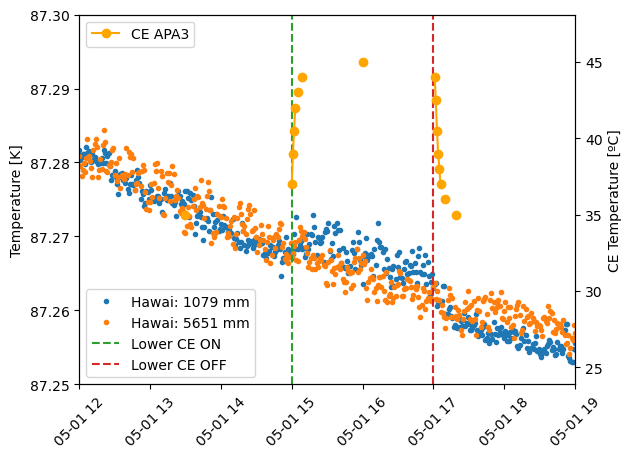

In [197]:
fig, axes = plt.subplots(1,1)
axes.plot(hawai.sensors[40011].data, ".", label="Hawai: 1079 mm")
axes.plot(hawai.sensors[40014].data, ".", label="Hawai: 5651 mm")
axes.set_ylim(87.25, 87.30)
axes.set_xlim(datetime.datetime(2024, 5, 1, 12), datetime.datetime(2024, 5, 1, 19))
axes.axvline(datetime.datetime(2024, 5, 1, 15, 0, 3), color="tab:green", linestyle="--", label="Lower CE ON")
axes.axvline(datetime.datetime(2024, 5, 1, 17, 0, 0), color="tab:red", linestyle="--", label="Lower CE OFF")
axes.legend(loc="lower left")
axes.set_ylabel("Temperature [K]")
plt.xticks(rotation=45)
axes2 = axes.twinx()
# axes2.plot(ce.sensors[1018].data, "o", color="red")
# axes2.plot(ce.sensors[1023].data, "o", color="green")
# axes2.plot(mux3.data, color="tab:orange")
# axes2.set_ylim(1.0006, 1.0008)
# axes2.plot(ce.sensors[1017].data, "-o", color="red", label="CE APA1")
axes2.plot(ce.sensors[1027].data, "-o", color="orange", label="CE APA3")
axes2.set_ylabel("CE Temperature [ºC]")
# axes2.plot(ce.sensors[1033].data, "-o", color="orange")
# axes2.plot(cryo.sensors[1048].data, color="green")
axes2.legend(loc="upper left")

Text(0, 0.5, 'Temperature [K]')

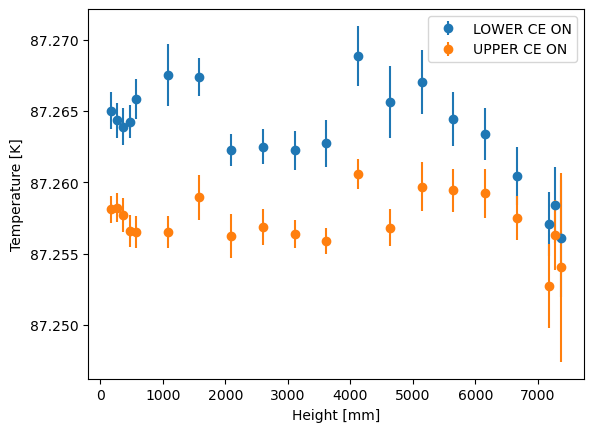

In [198]:
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 1, 15, 30, 0), tend=datetime.datetime(2024, 5, 1, 16, 30, 0))
p1 = hawai.profiles
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="LOWER CE ON", color="tab:blue")
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 30, 0), tend=datetime.datetime(2024, 5, 1, 18, 30, 0))
p2 = hawai.profiles
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="UPPER CE ON", color="tab:orange")
plt.legend();
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

Text(0.5, 0, 'Height [mm]')

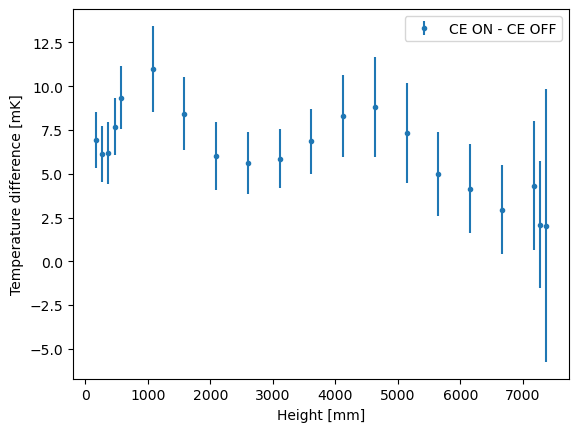

In [199]:
plt.errorbar(p1["Y"].values, 1e3*(p1["temp"].values - p2["temp"].values),
             yerr=1e3*np.sqrt(p1["err"]**2 + p2["err"]**2),
             fmt=".", color="tab:blue", label="CE ON - CE OFF")
plt.legend()
plt.ylabel("Temperature difference [mK]")
plt.xlabel("Height [mm]")

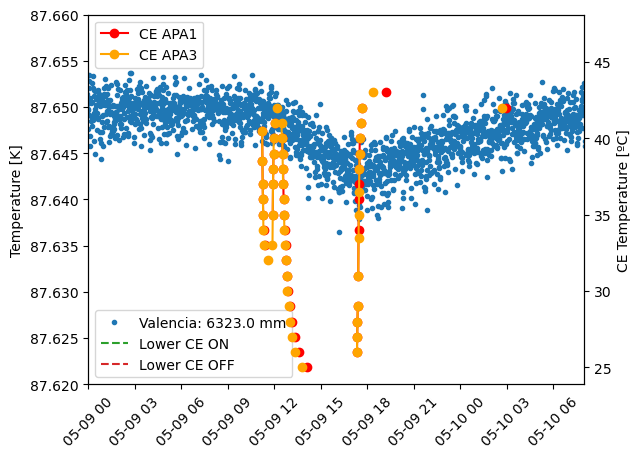

In [239]:
fig, axes = plt.subplots(1,1)
axes.plot(tgrad.sensors[39652].data, ".", label=f"Valencia: {tgrad.sensors[39652].Y} mm")
# axes.plot(tgrad.sensors[39613].data, ".", label="Hawai: 5651 mm")
axes.set_ylim(87.62, 87.66)
axes.set_xlim(datetime.datetime(2024, 5, 9, 0), datetime.datetime(2024, 5, 10, 8))
axes.axvline(datetime.datetime(2024, 5, 1, 15, 0, 3), color="tab:green", linestyle="--", label="Lower CE ON")
axes.axvline(datetime.datetime(2024, 5, 1, 17, 0, 0), color="tab:red", linestyle="--", label="Lower CE OFF")
axes.legend(loc="lower left")
axes.set_ylabel("Temperature [K]")
plt.xticks(rotation=45)
axes2 = axes.twinx()
# axes2.plot(ce.sensors[1018].data, "o", color="red")
# axes2.plot(ce.sensors[1023].data, "o", color="green")
# axes2.plot(mux3.data, color="tab:orange")
# axes2.set_ylim(1.0006, 1.0008)
axes2.plot(ce.sensors[1022].data, "-o", color="red", label="CE APA1")
axes2.plot(ce.sensors[1027].data, "-o", color="orange", label="CE APA3")
axes2.set_ylabel("CE Temperature [ºC]")
# axes2.plot(ce.sensors[1033].data, "-o", color="orange")
# axes2.plot(cryo.sensors[1048].data, color="green")
axes2.legend(loc="upper left")

Text(0, 0.5, 'Temperature [K]')

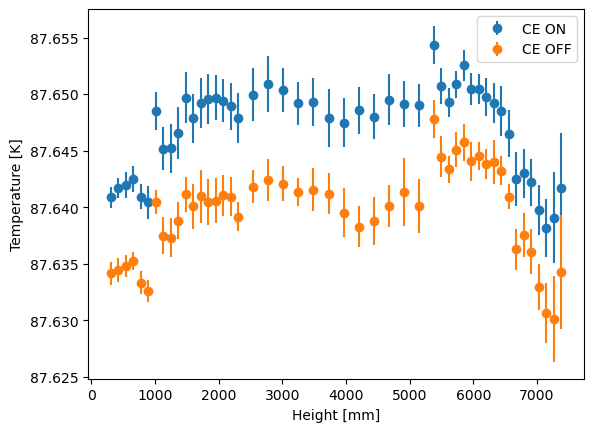

In [233]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 9, 8, 30, 0), tend=datetime.datetime(2024, 5, 9, 9, 30, 0))
p1 = tgrad.profiles
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="CE ON", color="tab:blue")
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 9, 16, 45, 0), tend=datetime.datetime(2024, 5, 9, 17, 0, 0))
p2 = tgrad.profiles
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="CE OFF", color="tab:orange")
plt.legend();
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

Text(0.5, 0, 'Height [mm]')

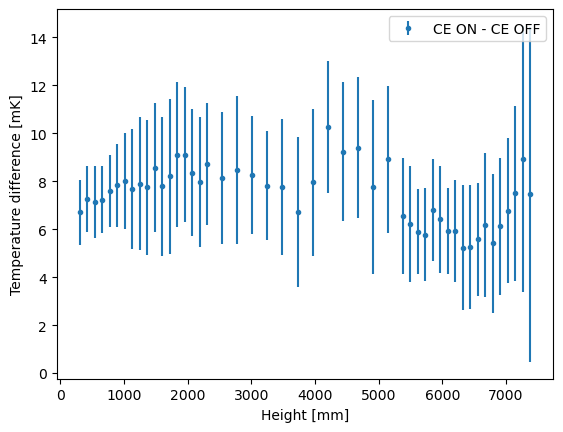

In [234]:
plt.errorbar(p1["Y"].values, 1e3*(p1["temp"].values - p2["temp"].values),
             yerr=1e3*np.sqrt(p1["err"]**2 + p2["err"]**2),
             fmt=".", color="tab:blue", label="CE ON - CE OFF")
plt.legend()
plt.ylabel("Temperature difference [mK]")
plt.xlabel("Height [mm]")

Text(0, 0.5, 'Temperature [K]')

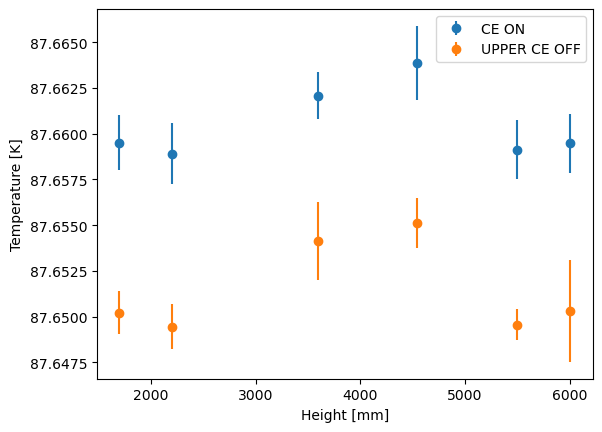

In [236]:
prm.makeProfiles(tini=datetime.datetime(2024, 5, 9, 8, 30, 0), tend=datetime.datetime(2024, 5, 9, 9, 30, 0))
p1 = prm.profiles
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="CE ON", color="tab:blue")
prm.makeProfiles(tini=datetime.datetime(2024, 5, 9, 16, 45, 0), tend=datetime.datetime(2024, 5, 9, 17, 0, 0))
p2 = prm.profiles
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="UPPER CE OFF", color="tab:orange")
plt.legend();
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

Text(0.5, 0, 'Height [mm]')

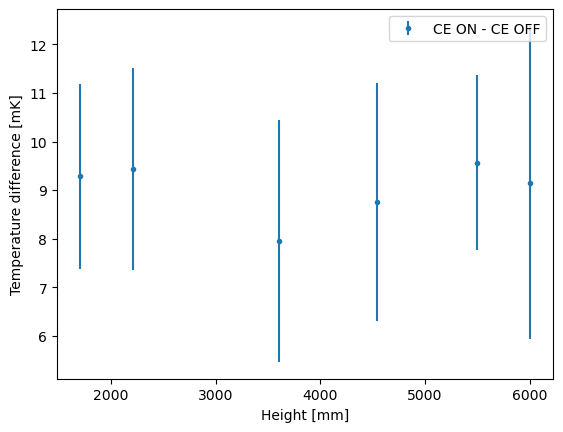

In [237]:
plt.errorbar(p1["Y"].values, 1e3*(p1["temp"].values - p2["temp"].values),
             yerr=1e3*np.sqrt(p1["err"]**2 + p2["err"]**2),
             fmt=".", color="tab:blue", label="CE ON - CE OFF")
plt.legend()
plt.ylabel("Temperature difference [mK]")
plt.xlabel("Height [mm]")